In [1]:
import sys
sys.path.append("/project/src")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from rsfmodel import RandomSurvivalForest
from preprocessing import (
    N_IMPORTANT_FEATURES,
    split_features_target,
    low_missingness_complete_case_analysis,
    decode_preprocessed_feature_name,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)

import joblib
import wandb

In [3]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "./data/nacc_data_2025.csv"

In [4]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')

/tmp/ipykernel_2560/2070981678.py:1: DtypeWarning: Columns (4,8,10,21,25,27,28,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,138,149,190,193,195,201,203,205,207,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,405,418,425,465,545,576,601,636,652,669,672,689,700,706,758,760,762,763,769,792,805,813,814,815,816,826,848,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')


In [5]:
nacc_raw.head()

,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,...,NPCOTH1,NPOTH1X,NPPOTH2,NPCOTH2,NPOTH2X,NPPOTH3,NPCOTH3,NPOTH3X,EVENT_MCI,TIME
0,1.0,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.487
1,NaN,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.035
2,2.0,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.474
3,1.0,2,0.0,NaN,NaN,1.0,NaN,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.025
4,NaN,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2.012


In [6]:
print(f"shape {nacc_raw.shape}")

shape (17477, 857)


In [7]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_preprocessed_train_data_csv = "/content/drive/MyDrive/bachelor/nacc_train_tunning_preprocessed.csv"
    nacc_train_raw_csv = "/content/drive/MyDrive/bachelor/nacc_train.csv"
else:
    nacc_preprocessed_train_data_csv = "./data/nacc_train_tunning_preprocessed.csv"
    nacc_train_raw_csv = "./data/nacc_train.csv"

In [8]:
nacc_preprocessed_train_df = pd.read_csv(nacc_preprocessed_train_data_csv, delimiter=',')
nacc_train_raw = pd.read_csv(nacc_train_raw_csv, delimiter=',')

/tmp/ipykernel_2560/1728453696.py:2: DtypeWarning: Columns (4,10,21,27,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,190,193,205,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,394,405,418,465,545,576,601,669,672,706,758,760,763,792,804,805,813,814,815,816,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_train_raw = pd.read_csv(nacc_train_raw_csv, delimiter=',')


In [9]:
nacc_preprocessed_train_df.shape

(6176, 346)

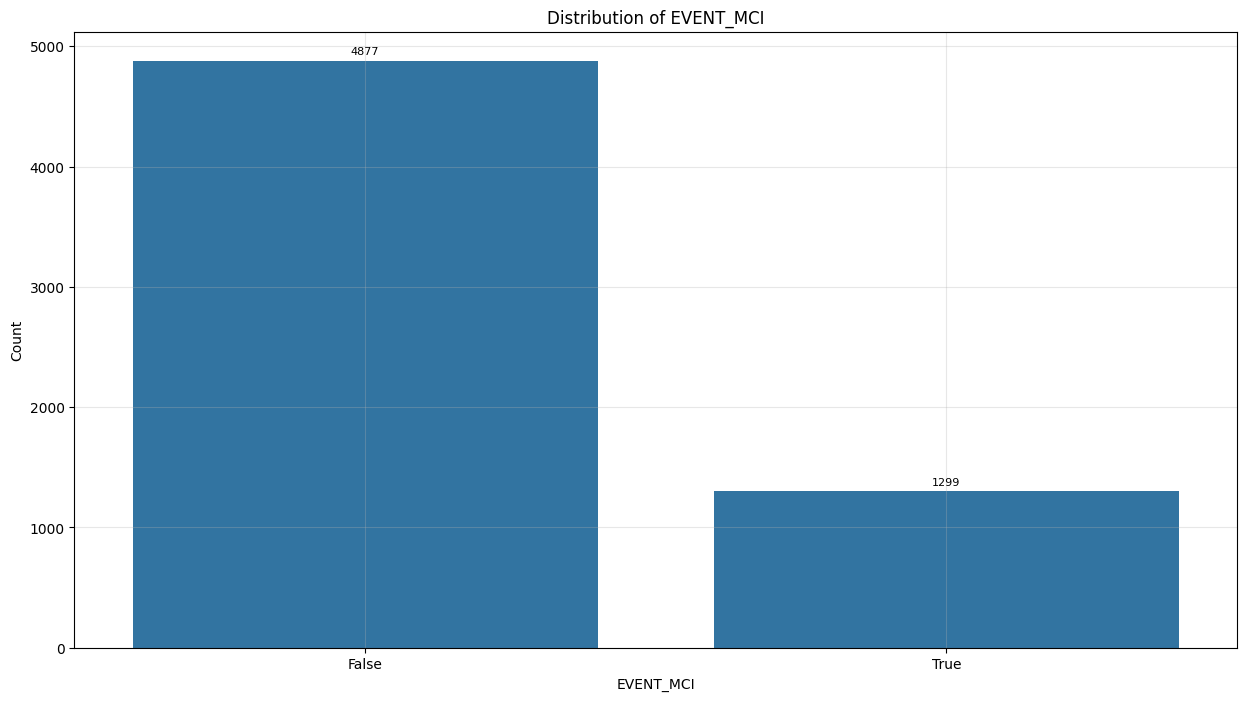

In [10]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=nacc_preprocessed_train_df['EVENT_MCI'].value_counts().index, y=nacc_preprocessed_train_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
nacc_preprocessed_train_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
False    0.78967
True     0.21033
Name: proportion, dtype: float64

## Feature selection function

In [12]:
def rsf_vimp_feature_selection(x_data, y_data, n_features, rsf_params):
    rsf = RandomSurvivalForest(
        num_trees       = rsf_params["num_trees"],
        mtry            = rsf_params["mtry"],
        min_node_size   = rsf_params["min_node_size"],
        replace         = rsf_params["replace"],
        sample_fraction = rsf_params["sample_fraction"],
        importance      = "permutation",
        compute_weights = True,
        OOB_score       = True,
    )
    rsf.fit(x_data, y_data)
    vimp_importance = rsf.get_importance()

    print("rsf.oob_score_():", rsf.oob_score_())
    return vimp_importance.head(n_features).index.tolist(), vimp_importance.head(n_features)


# Init wandb

In [13]:
# Start a new  run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="xportnykh-slovak-technical-university-in-bratislava",
    # Set the wandb project where this run will be logged.
    project="mci-survival-analysis",
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: xportnykh (xportnykh-slovak-technical-university-in-bratislava) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Fit dataset preprocessor on train data

In [14]:
best_parameters = joblib.load("joblib-storage/rsf_vimp_best_params_processed.joblib")

In [15]:
best_parameters

{'num_trees': np.int64(400),
 'mtry': 'sqrt',
 'min_node_size': 20,
 'replace': False,
 'sample_fraction': np.float64(0.6194516923834537)}

In [16]:
X_train_base_preprocessed, y_train_base_preprocessed = split_features_target(nacc_preprocessed_train_df)

In [17]:
selected_features_columns, selected_features_df = rsf_vimp_feature_selection(
    X_train_base_preprocessed, y_train_base_preprocessed, n_features=N_IMPORTANT_FEATURES, rsf_params=best_parameters
)

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  



Running Random Survival Forest with parameters: num_trees=400, min_node_size=20, mtry=sqrt, splitrule='C', importance='permutation', compute_weights=True, replace=False, sample_fraction=0.6194516923834537
Growing trees.. Progress: 6%. Estimated remaining time: 7 minutes, 45 seconds.
Growing trees.. Progress: 13%. Estimated remaining time: 7 minutes, 21 seconds.
Growing trees.. Progress: 19%. Estimated remaining time: 6 minutes, 34 seconds.
Growing trees.. Progress: 27%. Estimated remaining time: 5 minutes, 40 seconds.
Growing trees.. Progress: 35%. Estimated remaining time: 4 minutes, 52 seconds.
Growing trees.. Progress: 43%. Estimated remaining time: 4 minutes, 13 seconds.
Growing trees.. Progress: 51%. Estimated remaining time: 3 minutes, 33 seconds.
Growing trees.. Progress: 59%. Estimated remaining time: 2 minutes, 57 seconds.
Growing trees.. Progress: 67%. Estimated remaining time: 2 minutes, 19 seconds.
Growing trees.. Progress: 74%. Estimated remaining time: 1 minute, 49 secon

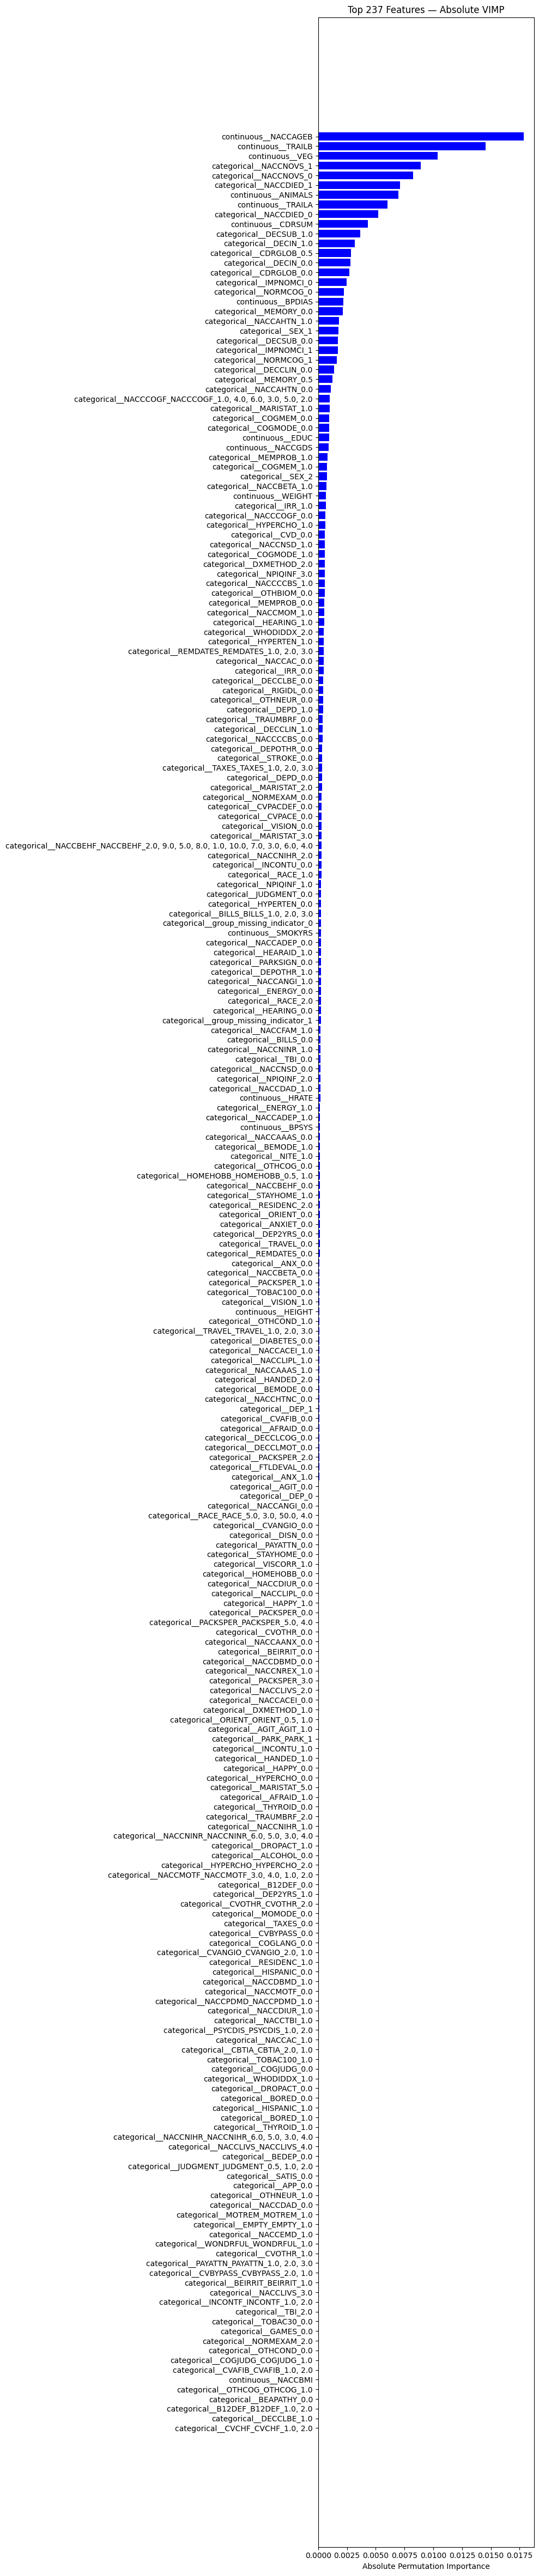

In [19]:
fig_abs, ax_abs = plt.subplots(figsize=(10, max(6, len(selected_features_df) * 0.2)))
sorted_abs = selected_features_df.sort_values("importances_mean_abs", ascending=True)
ax_abs.barh(sorted_abs.index, sorted_abs["importances_mean_abs"], color="blue")
ax_abs.set_xlabel("Absolute Permutation Importance")
ax_abs.set_title(f"Top {len(selected_features_df)} Features — Absolute VIMP")
plt.tight_layout()
plt.show()

In [20]:
wandb.log({"vimp/absolute_importance": wandb.Image(fig_abs)})

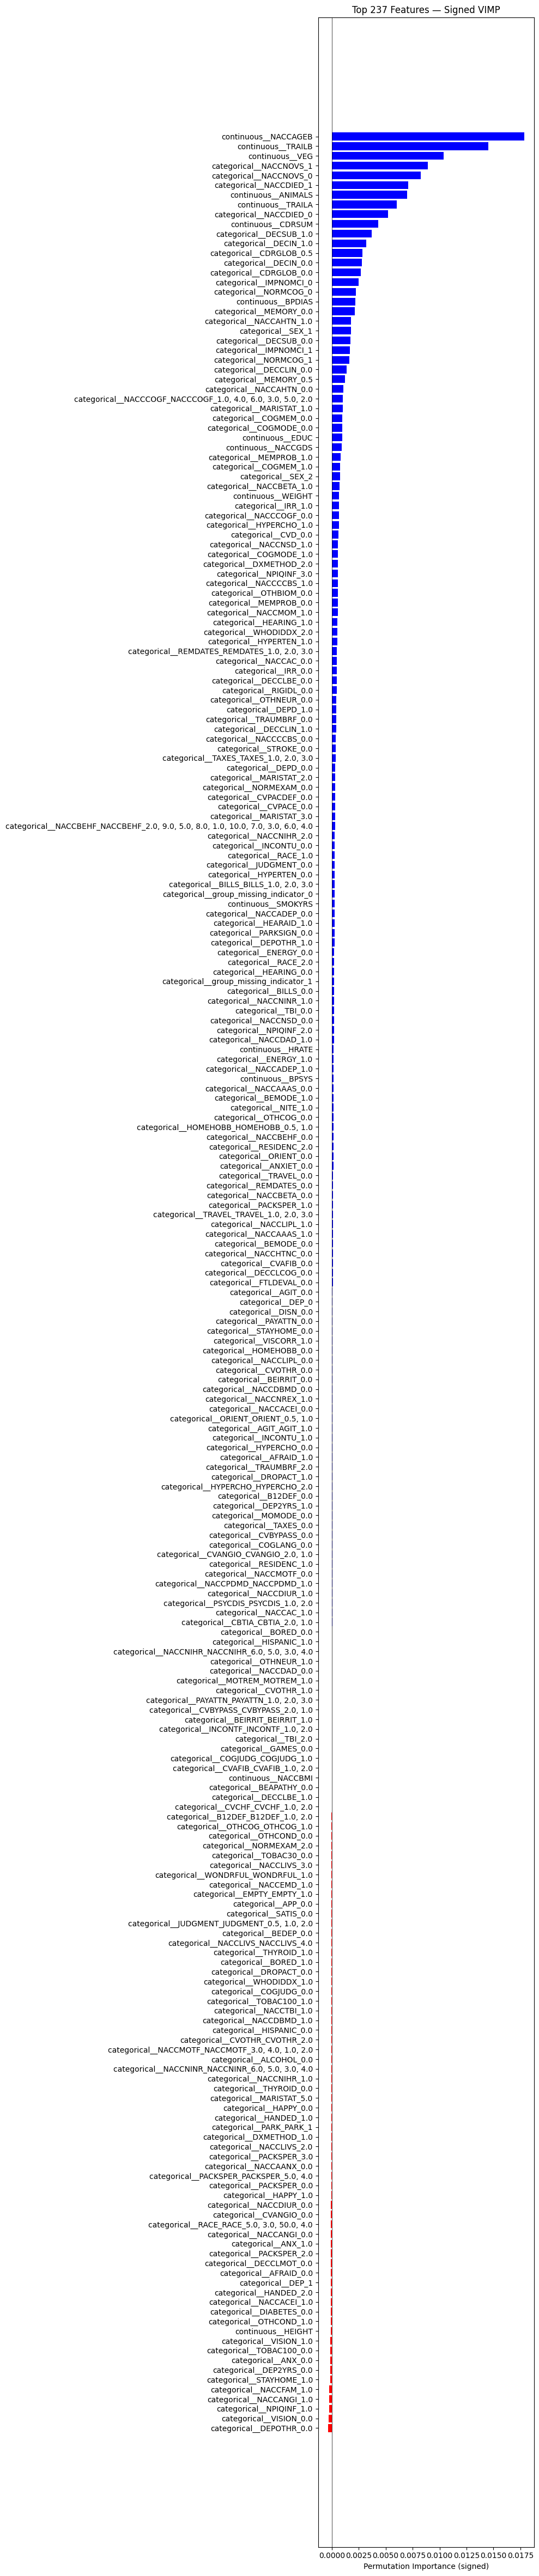

In [21]:
fig_signed, ax_signed = plt.subplots(figsize=(10, max(6, len(selected_features_df) * 0.2)))
sorted_signed = selected_features_df.sort_values("importances_mean", ascending=True)
colors = ["red" if v < 0 else "blue" for v in sorted_signed["importances_mean"]]
ax_signed.barh(sorted_signed.index, sorted_signed["importances_mean"], color=colors)
ax_signed.axvline(x=0, color="black", linewidth=0.5)
ax_signed.set_xlabel("Permutation Importance (signed)")
ax_signed.set_title(f"Top {len(selected_features_df)} Features — Signed VIMP")
plt.tight_layout()
plt.show()

In [22]:
wandb.log({"vimp/signed_importance": wandb.Image(fig_signed)})

In [23]:
# Decode preprocessed feature names back to raw column names
# Use nacc_raw columns as the reference for matching
raw_columns = nacc_raw.columns.tolist()
raw_feature_names = list(set(
    decode_preprocessed_feature_name(f, raw_columns, raw_columns)
    for f in selected_features_columns
))

# Select only the raw features + target, then complete case analysis on each split
target_cols = [SURVIVAL_EVENT_COL, SURVIVAL_TIME_COL]
available_raw_features = [c for c in raw_feature_names if c in nacc_raw.columns]

reduced_train = nacc_train_raw[available_raw_features + target_cols]
train_df_reduced = low_missingness_complete_case_analysis(reduced_train)

Complete-case analysis on low-missing columns
Defining missingness


In [24]:
X_train_reduced, y_train_reduced = split_features_target(train_df_reduced)

In [25]:
train_df_reduced.to_csv("./data/nacc_train_reduced.csv", index=False)

# Asses final data

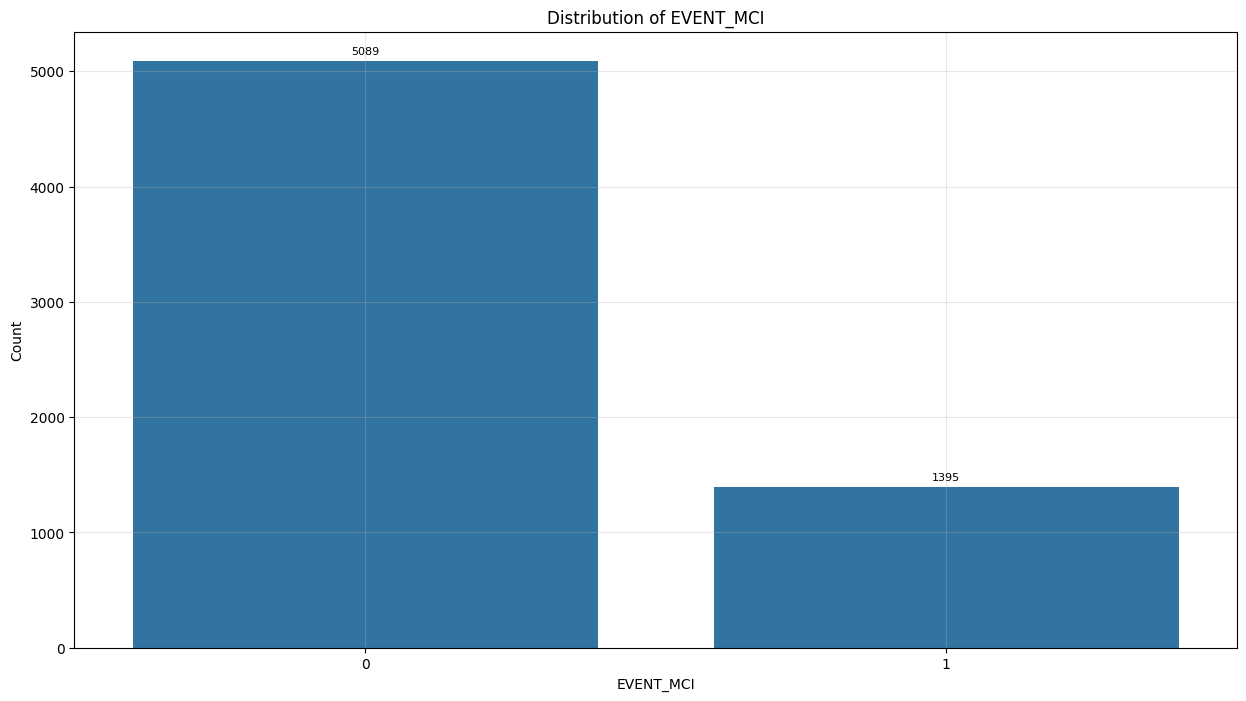

In [26]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=train_df_reduced['EVENT_MCI'].value_counts().index, y=train_df_reduced['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
train_df_reduced['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.784855
1    0.215145
Name: proportion, dtype: float64

In [28]:
train_df_reduced.shape

(6484, 142)

In [29]:
wandb.finish()